## Introduction

In recent years, online shopping has become increasingly popular due to the convenience, accessibility, and wide range of products available to 
consumers. E-commerce platforms such as Shopee, Lazada, and Amazon have transformed the way users interact with products and make purchasing 
decisions. However, despite the high volume of user traffic on these platforms, a significant number of users browse products without completing
their purchases. This phenomenon is commonly referred to as cart abandonment, and it poses a major challenge for businesses as it directly impacts 
sales performance and revenue generation.

Cart abandonment occurs when potential customers add items to their shopping cart but leave the platform before completing the transaction. 
This behaviour may be influenced by various factors, including pricing, discounts, product reviews, user experience, browsing patterns, 
and time spent on the platform. Understanding these behavioural patterns is crucial for businesses to improve customer engagement and increase 
conversion rates.

This project aims to address this issue by developing a machine learning model capable of predicting whether an online shopper will complete a 
purchase based on their browsing behaviour. By analysing relevant features such as discount availability, product ratings, browsing duration, and 
interaction frequency, the system can classify user behaviour into purchase or non-purchase outcomes. The model is built using supervised learning 
techniques, where historical data is used to train the system to recognize patterns and make predictions.

The implementation of this project not only demonstrates the practical application of machine learning in solving real-world problems but also
provides valuable insights into customer decision-making processes in e-commerce. The results of this study can assist businesses in identifying
potential buyers, optimizing marketing strategies, and improving overall user experience. Additionally, this project enhances understanding of data
preprocessing, model training, and evaluation within the context of classification problems.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Collection

The model is built using supervised learning techniques. To support this, a questionnaire in Google Forms was distributed via social media to a diverse age group to gather primary data on consumer habits and browsing preferences. A total of 166 respondents voluntarily completed the questionnaire. To ensure the integrity of the predictive model, the raw data underwent a preprocessing stage where redundant or duplicate responses were filtered out, resulting in 164 high-quality samples ready for analysis. Refer to the dataset file (Online Shopper Behavior.csv) for further information. 

In [2]:
df = pd.read_csv("/Users/husnaizzati/Documents/UNITEN/Semester 2 - 2025:2026/CSNB5213 (Machine Learning)/Group Project/Online Shopper Behaviour.csv")
df.head()

,Timestamp,What's your age?,How often do you shop online?,Which platform do you use the most,What type of products do you usually buy online?,How much time do you usually spend browsing before making a purchase?,How many pages/products do you view before buying?,Do you read product reviews before buying?,Do discounts influence your decision to buy ?,Does free shipping affect your decision ?,Do you trust online product ratings ?,Do you abandon your cart before completing purchase ?,Did you complete your purchase ?,What's the last item you purchased?
0,2026/04/10 1:31:03 AM GMT+8,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,B. 6 - 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
1,2026/04/10 1:31:20 AM GMT+8,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,B. 6 - 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
2,2026/04/10 1:37:28 AM GMT+8,B. 18 - 24,3,A. Shoppe,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
3,2026/04/10 1:40:58 AM GMT+8,B. 18 - 24,2,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,A. 1 - 5,Yes,Yes,Yes,Yes,Yes,No,NaN
4,2026/04/10 1:47:18 AM GMT+8,B. 18 - 24,3,A. Shoppe,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,Yes,No,NaN


In [3]:
df = df.drop_duplicates()
df

,Timestamp,What's your age?,How often do you shop online?,Which platform do you use the most,What type of products do you usually buy online?,How much time do you usually spend browsing before making a purchase?,How many pages/products do you view before buying?,Do you read product reviews before buying?,Do discounts influence your decision to buy ?,Does free shipping affect your decision ?,Do you trust online product ratings ?,Do you abandon your cart before completing purchase ?,Did you complete your purchase ?,What's the last item you purchased?
0,2026/04/10 1:31:03 AM GMT+8,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,B. 6 - 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
1,2026/04/10 1:31:20 AM GMT+8,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,B. 6 - 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
2,2026/04/10 1:37:28 AM GMT+8,B. 18 - 24,3,A. Shoppe,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
3,2026/04/10 1:40:58 AM GMT+8,B. 18 - 24,2,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,A. 1 - 5,Yes,Yes,Yes,Yes,Yes,No,NaN
4,2026/04/10 1:47:18 AM GMT+8,B. 18 - 24,3,A. Shoppe,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,Yes,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,2026/04/12 1:19:35 AM GMT+8,C. 25 - 34,3,A. Shoppe,B. Electronics,C. More than 15 minutes,C. More than 10,Yes,No,No,Yes,Yes,Yes,Iphone 17 Pro Max
160,2026/04/12 1:21:09 AM GMT+8,C. 25 - 34,3,A. Shoppe,A. Clothing,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,No,No,Yes,Jeans
161,2026/04/12 1:21:54 AM GMT+8,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,No,Yes,Yes,Yes,Yes,Toner
162,2026/04/12 1:22:43 AM GMT+8,B. 18 - 24,3,NaN,E. Others,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,No,Yes,Briik bag


## Data Cleaning

To ensure the dataset was suitable for machine learning analysis, several data cleaning steps were performed to improve data quality and consistency:

Feature Selection (Dropping Irrelevant Columns): The Timestamp column, which records the exact time each respondent submitted the Google Form, was removed. This attribute is a metadata artifact of the collection process and does not hold any predictive value for consumer browsing habits or purchase decisions.

Standardizing Missing Values: In the column "What's the last item you purchased?", inconsistent entries such as 'N/a' were standardized to 'NaN' (Not a Number). This ensures that the machine learning model correctly identifies these cells as missing data rather than unique text strings, allowing for more accurate data imputation or filtering later.

Deduplication: To maintain the integrity of the primary data, the dataset was checked for duplicate entries. This resulted in a refined dataset of 164 unique responses, providing a solid foundation for the subsequent training of the supervised learning model.

In [4]:
df = df.drop(columns = "Timestamp")
df

,What's your age?,How often do you shop online?,Which platform do you use the most,What type of products do you usually buy online?,How much time do you usually spend browsing before making a purchase?,How many pages/products do you view before buying?,Do you read product reviews before buying?,Do discounts influence your decision to buy ?,Does free shipping affect your decision ?,Do you trust online product ratings ?,Do you abandon your cart before completing purchase ?,Did you complete your purchase ?,What's the last item you purchased?
0,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,B. 6 - 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
1,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,B. 6 - 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
2,B. 18 - 24,3,A. Shoppe,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
3,B. 18 - 24,2,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,A. 1 - 5,Yes,Yes,Yes,Yes,Yes,No,NaN
4,B. 18 - 24,3,A. Shoppe,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,Yes,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,C. 25 - 34,3,A. Shoppe,B. Electronics,C. More than 15 minutes,C. More than 10,Yes,No,No,Yes,Yes,Yes,Iphone 17 Pro Max
160,C. 25 - 34,3,A. Shoppe,A. Clothing,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,No,No,Yes,Jeans
161,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,No,Yes,Yes,Yes,Yes,Toner
162,B. 18 - 24,3,NaN,E. Others,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,No,Yes,Briik bag


## Target Variable Distribution

After data cleaning, a distribution analysis was performed on the target variable, 'Did you complete your purchase?'. The results showed that 141 respondents (86%) completed their purchase, while 23 (14%) did not. This step was crucial for identifying class imbalance, which informs the selection of evaluation metrics—such as F1-score or Precision-Recall—rather than relying solely on accuracy during model training.

In [6]:
df["What's the last item you purchased?"] = df["What's the last item you purchased?"].str.replace('N/a', 'NaN')
df

,What's your age?,How often do you shop online?,Which platform do you use the most,What type of products do you usually buy online?,How much time do you usually spend browsing before making a purchase?,How many pages/products do you view before buying?,Do you read product reviews before buying?,Do discounts influence your decision to buy ?,Does free shipping affect your decision ?,Do you trust online product ratings ?,Do you abandon your cart before completing purchase ?,Did you complete your purchase ?,What's the last item you purchased?
0,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,B. 6 - 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
1,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,B. 6 - 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
2,B. 18 - 24,3,A. Shoppe,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
3,B. 18 - 24,2,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,A. 1 - 5,Yes,Yes,Yes,Yes,Yes,No,NaN
4,B. 18 - 24,3,A. Shoppe,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,Yes,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,C. 25 - 34,3,A. Shoppe,B. Electronics,C. More than 15 minutes,C. More than 10,Yes,No,No,Yes,Yes,Yes,Iphone 17 Pro Max
160,C. 25 - 34,3,A. Shoppe,A. Clothing,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,No,No,Yes,Jeans
161,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,No,Yes,Yes,Yes,Yes,Toner
162,B. 18 - 24,3,NaN,E. Others,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,No,Yes,Briik bag


In [8]:
df["Did you complete your purchase ?"].value_counts()

Did you complete your purchase ?
Yes    141
No      23
Name: count, dtype: int64

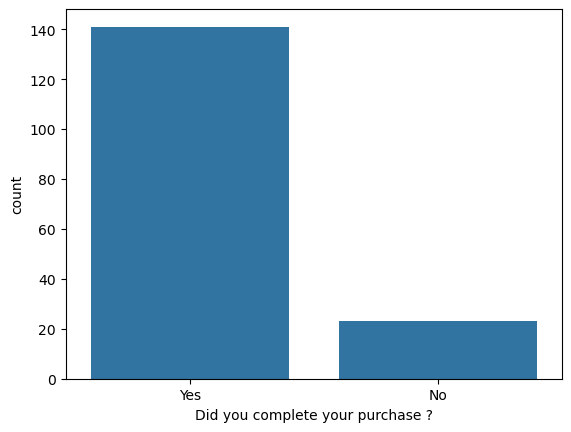

In [10]:
sns.countplot(x="Did you complete your purchase ?", data=df)
plt.show()

In [14]:
print(df.columns)

Index(['What's your age?', 'How often do you shop online?',
       'Which platform do you use the most',
       'What type of products do you usually buy online?',
       'How much time do you usually spend browsing before making a purchase?',
       'How many pages/products do you view before buying?',
       'Do you read product reviews before buying?',
       'Do discounts influence your decision to buy ? ',
       'Does free shipping affect your decision ?',
       'Do you trust online product ratings ?',
       'Do you abandon your cart before completing purchase ?',
       'Did you complete your purchase ?',
       'What's the last item you purchased?'],
      dtype='object')


In [18]:
df.columns = df.columns.str.strip()

In [20]:
df.columns = df.columns.str.strip()

In [21]:
df.rename(columns={
    "What's your age?": "age",
    "How often do you shop online?": "frequency",
    "Which platform do you use the most": "platform",
    "What type of products do you usually buy online?": "product_type",
    "How much time do you usually spend browsing before making a purchase?": "browsing_time",
    "How many pages/products do you view before buying?": "pages_viewed",
    "Do you read product reviews before buying?": "reviews",
    "Do discounts influence your decision to buy ?": "discount",
    "Does free shipping affect your decision ?": "free_shipping",
    "Do you trust online product ratings ?": "trust",
    "Do you abandon your cart before completing purchase ?": "cart_abandon",
    "Did you complete your purchase ?": "purchase",
    "What's the last item you purchased?": "last_item"
}, inplace=True)

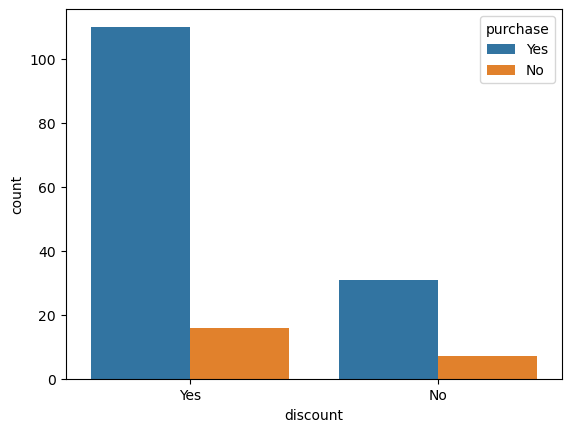

In [22]:
sns.countplot(x="discount", hue="purchase", data=df)
plt.show()

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

## Label Encoding

Machine learning models cannot process categorical text data directly. Therefore, Label Encoding is used to convert categorical values into numerical values.

For example:

Yes = 1
No = 0

This step prepares the dataset for machine learning model training.

In [24]:
x = df.drop("purchase", axis=1)
y = df["purchase"]

## Feature and Target Separation

The dataset is divided into:
- Features (X) → Input variables used for prediction
- Target Variable (y) → Output variable to predict purchase completion

The target variable for this project is:
"purchase"

In [26]:
print(df.columns)

Index(['age', 'frequency', 'platform', 'product_type', 'browsing_time',
       'pages_viewed', 'reviews', 'discount', 'free_shipping', 'trust',
       'cart_abandon', 'purchase', 'last_item'],
      dtype='object')


In [27]:
X = df.drop("purchase", axis=1)
y = df["purchase"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training
- 20% is used for testing

The training set is used to train the machine learning model, while the testing set is used to evaluate prediction performance on unseen data.

In [46]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

## Logistic Regression Model

Logistic Regression is used as the main machine learning algorithm for this project.

This algorithm is suitable because the project involves binary classification:
- Purchase = Yes
- Purchase = No

The model learns patterns from user shopping behaviour to predict purchase completion.

In [47]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

## Decision Tree Model

A Decision Tree Classifier is also implemented as a comparison model.

This allows comparison between two machine learning algorithms to determine which produces better prediction accuracy.

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Logistic Accuracy:", accuracy_score(y_test, y_pred1))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))

Logistic Accuracy: 0.9393939393939394
Decision Tree Accuracy: 0.8787878787878788


## Model Evaluation

The models are evaluated using accuracy score.

Accuracy measures how many predictions are correctly predicted by the machine learning model.

In [32]:
print(confusion_matrix(y_test, y_pred1))

[[ 0  2]
 [ 0 31]]


## Confusion Matrix

The confusion matrix is used to evaluate classification performance.

It shows:
- Correct predictions
- Incorrect predictions

This helps analyze how well the model predicts purchase completion.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r"C:\Users\yasmi\Downloads\Online Shopper Behaviour (Responses).xlsx")

df.head()

,Timestamp,What's your age?,How often do you shop online?,Which platform do you use the most,What type of products do you usually buy online?,How much time do you usually spend browsing before making a purchase?,How many pages/products do you view before buying?,Do you read product reviews before buying?,Do discounts influence your decision to buy ?,Does free shipping affect your decision ?,Do you trust online product ratings ?,Do you abandon your cart before completing purchase ?,Did you complete your purchase ?,What's the last item you purchased?
0,2026-04-10 01:31:03.852,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,B. 6 - 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
1,2026-04-10 01:31:20.879,B. 18 - 24,3,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,B. 6 - 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
2,2026-04-10 01:37:28.415,B. 18 - 24,3,A. Shoppe,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,Yes,Yes,NaN
3,2026-04-10 01:40:58.692,B. 18 - 24,2,C. TikTok Shop,D. Beauty & Products,C. More than 15 minutes,A. 1 - 5,Yes,Yes,Yes,Yes,Yes,No,NaN
4,2026-04-10 01:47:18.196,B. 18 - 24,3,A. Shoppe,D. Beauty & Products,C. More than 15 minutes,C. More than 10,Yes,Yes,Yes,Yes,Yes,No,NaN


#**Data Visualization**

In [6]:
df = df.drop_duplicates()
if 'Timestamp' in df.columns:
    df = df.drop(columns=['Timestamp'])

df["What's the last item you purchased?"] = df["What's the last item you purchased?"].str.replace('N/a', 'NaN')

In [7]:
df.rename(columns={
    "What's your age?": "age",
    "How often do you shop online?": "frequency",
    "Which platform do you use the most": "platform",
    "What type of products do you usually buy online?": "product_type",
    "How much time do you usually spend browsing before making a purchase?": "browsing_time",
    "How many pages/products do you view before buying?": "pages_viewed",
    "Do you read product reviews before buying?": "reviews",
    "Do discounts influence your decision to buy ?": "discount",
    "Does free shipping affect your decision ?": "free_shipping",
    "Do you trust online product ratings ?": "trust",
    "Do you abandon your cart before completing purchase ?": "cart_abandon",
    "Did you complete your purchase ?": "purchase",
    "What's the last item you purchased?": "last_item"
}, inplace=True)

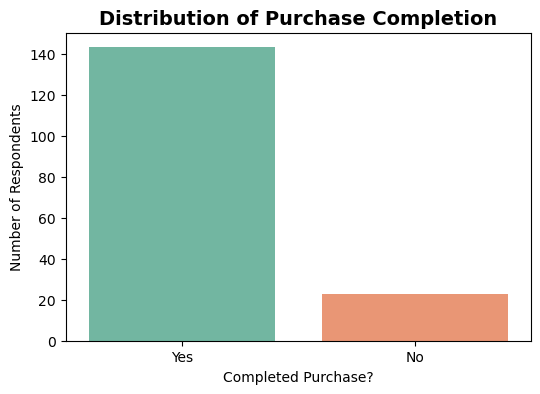

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='purchase', data=df, hue='purchase', legend=False, palette='Set2')
plt.title('Distribution of Purchase Completion', fontsize=14, fontweight='bold')
plt.xlabel('Completed Purchase?')
plt.ylabel('Number of Respondents')
plt.show()

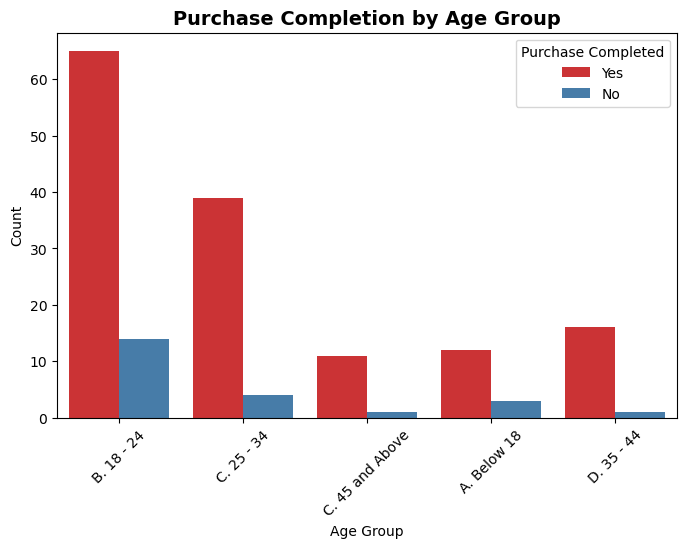

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='age', hue='purchase', data=df, palette='Set1')
plt.title('Purchase Completion by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Purchase Completed')
plt.xticks(rotation=45)
plt.show()

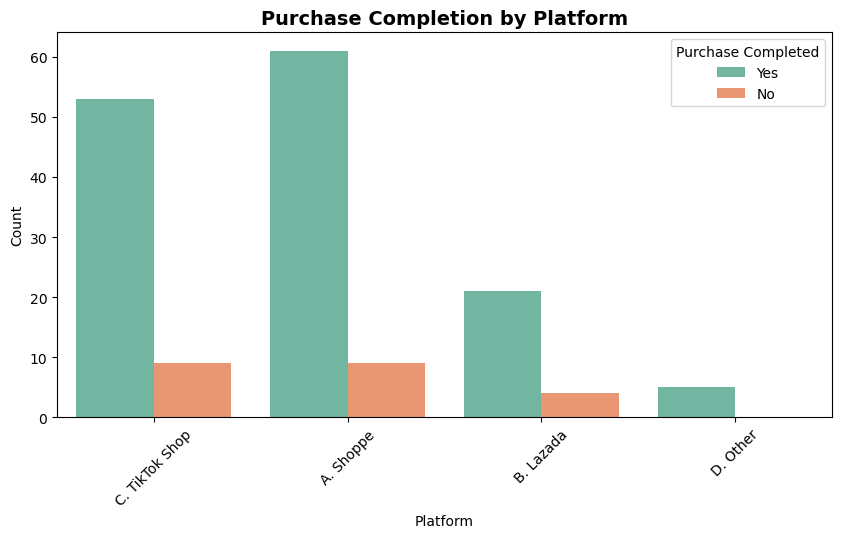

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(x='platform', hue='purchase', data=df, palette='Set2')
plt.title('Purchase Completion by Platform', fontsize=14, fontweight='bold')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.legend(title='Purchase Completed')
plt.xticks(rotation=45)
plt.show()

In [19]:
print("EXACT column names:")
for col in df.columns:
    print(f"'{col}'")
    

EXACT column names:
'age'
'frequency'
'platform'
'product_type'
'browsing_time'
'pages_viewed'
'reviews'
'Do discounts influence your decision to buy ? '
'free_shipping'
'trust'
'cart_abandon'
'purchase'
'last_item'


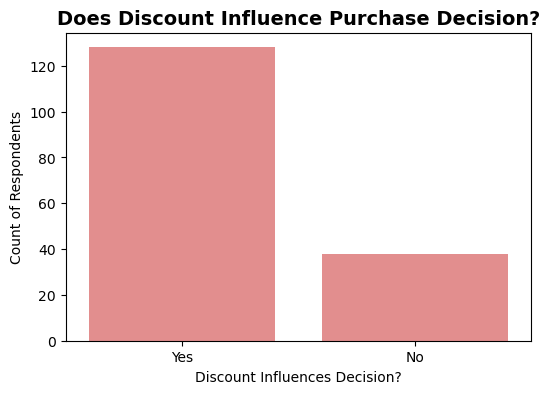

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='Do discounts influence your decision to buy ? ', data=df, color='lightcoral')
plt.title('Does Discount Influence Purchase Decision?', fontsize=14, fontweight='bold')
plt.xlabel('Discount Influences Decision?')
plt.ylabel('Count of Respondents')
plt.show()

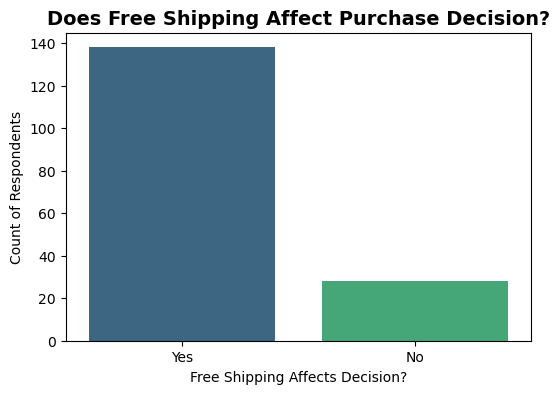

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='free_shipping', data=df, hue='free_shipping', legend=False, palette='viridis')
plt.title('Does Free Shipping Affect Purchase Decision?', fontsize=14, fontweight='bold')
plt.xlabel('Free Shipping Affects Decision?')
plt.ylabel('Count of Respondents')
plt.show()

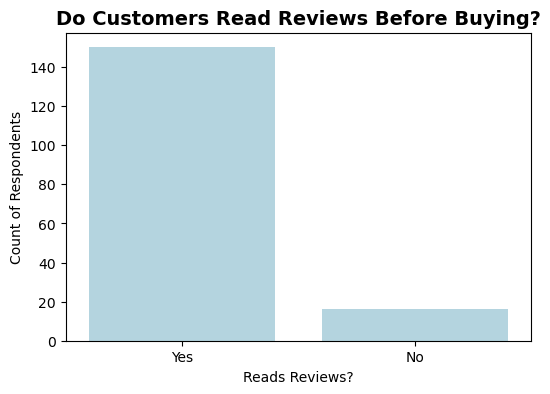

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(x='reviews', data=df, color='lightblue')
plt.title('Do Customers Read Reviews Before Buying?', fontsize=14, fontweight='bold')
plt.xlabel('Reads Reviews?')
plt.ylabel('Count of Respondents')
plt.show()

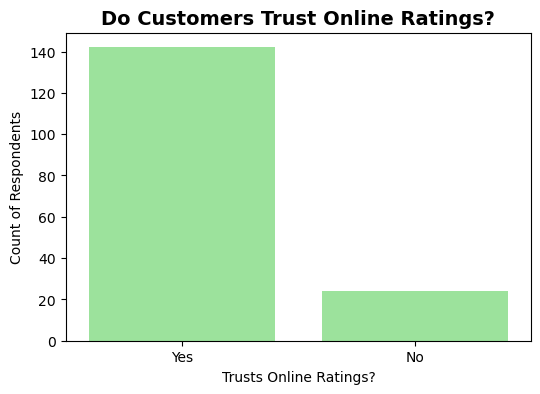

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(x='trust', data=df, color='lightgreen')
plt.title('Do Customers Trust Online Ratings?', fontsize=14, fontweight='bold')
plt.xlabel('Trusts Online Ratings?')
plt.ylabel('Count of Respondents')
plt.show()

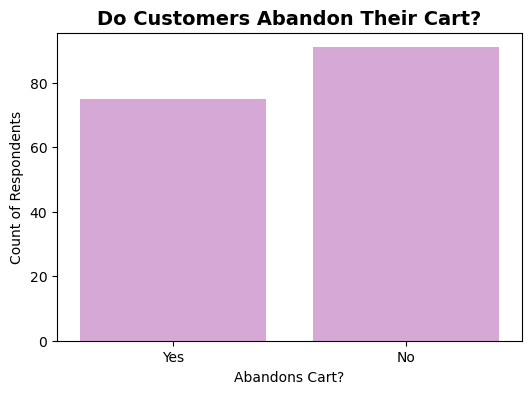

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='cart_abandon', data=df, color='plum')
plt.title('Do Customers Abandon Their Cart?', fontsize=14, fontweight='bold')
plt.xlabel('Abandons Cart?')
plt.ylabel('Count of Respondents')
plt.show()

**Model Training**

In [40]:
print("X (features) shape:", X.shape if 'X' in dir() else "Not created yet")
print("y (target) shape:", y.shape if 'y' in dir() else "Not created yet")

X (features) shape: Not created yet
y (target) shape: Not created yet


In [41]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop('purchase', axis=1)
y = df_encoded['purchase']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution (0=No, 1=Yes):")
print(y.value_counts())

Features shape: (166, 12)
Target shape: (166,)

Target distribution (0=No, 1=Yes):
purchase
1    143
0     23
Name: count, dtype: int64


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 132
Test set size: 34


In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred1):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred1)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred1, zero_division=0)}")

print("\nDecision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred2):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred2)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred2, zero_division=0)}")

Logistic Regression Results:
Accuracy: 0.9412
Confusion Matrix:
[[ 0  0]
 [ 2 32]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.94      0.97        34

    accuracy                           0.94        34
   macro avg       0.50      0.47      0.48        34
weighted avg       1.00      0.94      0.97        34


Decision Tree Results:
Accuracy: 0.8529
Confusion Matrix:
[[ 0  0]
 [ 5 29]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.85      0.92        34

    accuracy                           0.85        34
   macro avg       0.50      0.43      0.46        34
weighted avg       1.00      0.85      0.92        34



**Model Evaluation**
Three models were evaluated using accuracy, confusion matrix, and classification report:

**Logistic Regression:**
- Accuracy: 94.12%
- Confusion Matrix: [[0, 0], [2, 32]]
- Precision (Yes): 1.00
- Recall (Yes): 0.94
- F1-Score (Yes): 0.97

**Decision Tree:**
- Accuracy: 85.29%
- Confusion Matrix: [[0, 0], [5, 29]]
- Precision (Yes): 1.00
- Recall (Yes): 0.85
- F1-Score (Yes): 0.92